# V3 Analysis: Does the Size of a Team's Largest Contract Predict Franchise Valuation Growth?

**Goal:** For each NBA team, find their largest contract (by AAV), then measure whether franchise valuation grew faster than the league average after that contract started — and whether bigger contracts predict bigger valuation gains.

**Why we adjust for league-average growth:**
NBA franchise valuations rise every single year leaguewide. Without adjusting, every team would look like it benefited from signing a big contract. We measure each team's growth *relative to the league average* for that same period to isolate the team-specific effect.

**The two questions we answer:**
- Does a team's valuation grow faster than league average *after* signing their largest contract?
- Does a *larger* contract predict *larger* above-average valuation growth?

---
## Block 1 — Imports and Settings

- Load all libraries we need
- **`WINDOW`** is the key setting: change it to `1` or `2` to control how many years before/after the contract start year are compared
- All file paths point to the `data/` folder

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# ── KEY SETTING ────────────────────────────────────────────────────────────────────
# Change this to 1 or 2 to switch between window sizes
WINDOW = 1   # years before AND after the contract start year
# ─────────────────────────────────────────────────────────────────────────

DATA_DIR = 'data/'

print(f'Window size set to: {WINDOW} year(s) before and after contract start')

Window size set to: 1 year(s) before and after contract start


---
## Block 2 — Load the Data

- Load the two files we need: contracts and franchise valuations
- The valuation file has a blank row at the top, so we use `skiprows=1` to skip it
- Print shapes to confirm both loaded correctly

In [15]:
contracts_raw = pd.read_csv(DATA_DIR + 'NBA_Contracts.csv')
valuation_raw = pd.read_csv(DATA_DIR + 'NBA_Team_Valuation.csv',skiprows=0, header=1)

print('Contracts shape:', contracts_raw.shape)
print('Valuation shape:', valuation_raw.shape)
print('\nValuation columns:', valuation_raw.columns.tolist())
print('\nValuation sample (first 3 rows):')
print(valuation_raw.head(3).to_string())

Contracts shape: (583, 11)
Valuation shape: (23, 31)

Valuation columns: ['Year', 'Hawks', 'Celtics', 'Nets', 'Hornets', 'Bulls', 'Cavs', 'Mavericks', 'Nuggets', 'Pistons', 'Warriors', 'Rockets', 'Pacers', 'Clippers', 'Lakers', 'Grizzlies', 'Heat', 'Bucks', 'Timberwolves', 'Pelicans', 'Knicks', 'Thunder', 'Magic', '76ers', 'Suns', 'Trail Blazers', 'Kings', 'Spurs', 'Raptors', 'Jazz', 'Wizards']

Valuation sample (first 3 rows):
   Year Hawks Celtics Nets Hornets Bulls Cavs Mavericks Nuggets Pistons Warriors Rockets Pacers Clippers Lakers Grizzlies Heat Bucks Timberwolves Pelicans Knicks Thunder Magic 76ers Suns Trail Blazers Kings Spurs Raptors Jazz Wizards
0  2003   206     274  218     NaN   323  222       304     209     258      176     255    246      205    426       198  250   168          213      172    398     207   197   298  272           270   259   242     217  226     278
1  2004   202     290  244     NaN   356  258       338     218     284      188     278    280     

---
## Block 3 — Clean the Contracts Data

- The `Team` column has extra whitespace and a duplicate abbreviation (e.g. `'MEM   MEM'`) — we extract just the first word
- `NOP` and `NYK` are fixed to `NO` and `NY` to match the valuation file's team names
- `AAV` is converted from a string like `'$62,786,682'` to a float
- Coaches (`COA`) are dropped since we only care about player contracts

In [16]:
contracts = contracts_raw.copy()

# Clean column names
contracts.columns = contracts.columns.str.strip()
contracts = contracts.rename(columns={'Team                     Currently With': 'Team'})

# Extract just the first abbreviation (e.g. 'MEM   MEM' -> 'MEM')
contracts['Team'] = contracts['Team'].str.strip().str.split().str[0]

# Fix abbreviations so they align with the valuation file mapping below
abbrev_fix = {'NOP': 'NO', 'NYK': 'NY'}
contracts['Team'] = contracts['Team'].replace(abbrev_fix)

# Convert AAV from '$62,786,682' to a float
contracts['AAV_clean'] = (
    contracts['AAV']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Drop coaches
contracts = contracts[contracts['Pos'] != 'COA'].copy()

print('Cleaned contracts shape:', contracts.shape)
print('\nSample rows:')
contracts[['Player', 'Team', 'Pos', 'Start', 'AAV_clean']].head(8)

Cleaned contracts shape: (582, 12)

Sample rows:


,Player,Team,Pos,Start,AAV_clean
0,Jayson Tatum,BOS,PF,2025,62786682.0
1,Jaylen Brown,BOS,SF,2024,57078728.0
2,Nikola Jokic,DEN,C,2023,55224526.0
3,Shai Gilgeous-Alexander,OKC,PG,2027,67914000.0
4,Evan Mobley,CLE,PF,2025,53817156.0
5,Cade Cunningham,DET,PG,2025,53817156.0
6,Anthony Edwards,MIN,SG,2024,48924624.0
7,Tyrese Haliburton,IND,PG,2024,48924624.0


---
## Block 4 — Find Each Team's Largest Contract (by AAV)

- For each team, keep only the one contract with the highest AAV
- This is our "event" — the signing we'll measure the before/after valuation effect of
- Filter to contracts starting between 2021 and 2024 so both before and after valuation data exists
  - Valuation data covers 2003–2025, and we need at least one year on each side

In [17]:
# For each team, get the row with the highest AAV
idx = contracts.groupby('Team')['AAV_clean'].idxmax()
top_contracts = contracts.loc[idx].copy()

# Keep only contracts where before/after valuation data exists
top_contracts = top_contracts[top_contracts['Start'] >= 2021].copy()
top_contracts = top_contracts[top_contracts['Start'] <= 2024].copy()

top_contracts = top_contracts.reset_index(drop=True)

print(f'Teams with usable top contracts: {len(top_contracts)}')
print('\nTop contract per team:')
top_contracts[['Team', 'Player', 'Pos', 'Start', 'AAV_clean']].sort_values('AAV_clean', ascending=False)

Teams with usable top contracts: 13

Top contract per team:


,Team,Player,Pos,Start,AAV_clean
3,DEN,Nikola Jokic,C,2023,55224526.0
10,NY,Karl-Anthony Towns,C,2024,55110496.0
6,LAC,Kawhi Leonard,SF,2024,49835267.0
5,IND,Tyrese Haliburton,PG,2024,48924624.0
8,MIN,Anthony Edwards,SG,2024,48924624.0
4,HOU,Kevin Durant,SF,2022,48554830.0
12,SAC,Domantas Sabonis,PF,2024,46504000.0
2,CHA,LaMelo Ball,PG,2024,40770520.0
7,MEM,Ja Morant,PG,2023,39446090.0
9,NO,Zion Williamson,PF,2023,39446090.0


---
## Block 5 — Clean and Reshape the Valuation Data

- The valuation file is **wide format**: one row per year, one column per team name (e.g. `Knicks`)
- We reshape it to **long format**: one row per team per year — easier to filter and merge
- We map full team names to abbreviations so they match the contracts file
- Values are in $millions (e.g. `426` = $426M)

In [19]:
valuation = valuation_raw.copy()

# Drop any rows where Year is missing
valuation = valuation.dropna(subset=['Year']).copy()
valuation['Year'] = valuation['Year'].astype(int)

# Reshape from wide to long
valuation_long = valuation.melt(id_vars='Year', var_name='team_name', value_name='valuation_m')
valuation_long['valuation_m'] = (
    valuation_long['valuation_m']
    .astype(str)
    .str.replace(',', '', regex=False)
)
valuation_long['valuation_m'] = pd.to_numeric(valuation_long['valuation_m'], errors='coerce')
valuation_long = valuation_long.dropna(subset=['valuation_m']).copy()

# Map full team names to the abbreviations used in the contracts file
name_to_abbrev = {
    'Hawks':         'ATL',  'Celtics':       'BOS',  'Nets':          'BKN',
    'Hornets':       'CHA',  'Bulls':         'CHI',  'Cavs':          'CLE',
    'Mavericks':     'DAL',  'Nuggets':       'DEN',  'Pistons':       'DET',
    'Warriors':      'GS',   'Rockets':       'HOU',  'Pacers':        'IND',
    'Clippers':      'LAC',  'Lakers':        'LAL',  'Grizzlies':     'MEM',
    'Heat':          'MIA',  'Bucks':         'MIL',  'Timberwolves':  'MIN',
    'Pelicans':      'NO',   'Knicks':        'NY',   'Thunder':       'OKC',
    'Magic':         'ORL',  '76ers':         'PHI',  'Suns':          'PHX',
    'Trail Blazers': 'POR',  'Kings':         'SAC',  'Spurs':         'SA',
    'Raptors':       'TOR',  'Jazz':          'UTAH', 'Wizards':       'WSH',
}
valuation_long['team'] = valuation_long['team_name'].map(name_to_abbrev)
valuation_long = valuation_long.dropna(subset=['team']).copy()

print('Valuation long format shape:', valuation_long.shape)
print('Year range:', valuation_long['Year'].min(), '—', valuation_long['Year'].max())
print('\nSample rows:')
valuation_long[['Year', 'team', 'valuation_m']].head(10)

Valuation long format shape: (687, 4)
Year range: 2003 — 2025

Sample rows:


,Year,team,valuation_m
0,2003,ATL,206.0
1,2004,ATL,202.0
2,2005,ATL,232.0
3,2006,ATL,262.0
4,2007,ATL,275.0
5,2008,ATL,286.0
6,2009,ATL,306.0
7,2010,ATL,306.0
8,2011,ATL,295.0
9,2012,ATL,270.0


---
## Block 6 — Verify Team Abbreviations Match

- Before running the main analysis, confirm that the team abbreviations in the contracts file
  actually exist in the valuation file
- Any mismatches here will cause teams to be silently skipped in Block 7
- If you see teams listed under "In contracts but NOT in valuation", the name_to_abbrev map in Block 5 needs updating

In [20]:
contract_teams  = set(top_contracts['Team'].unique())
valuation_teams = set(valuation_long['team'].unique())

missing = contract_teams - valuation_teams
matched = contract_teams & valuation_teams

print(f'Teams that WILL be included ({len(matched)}):')
print(sorted(matched))
print(f'\nTeams that will be SKIPPED — abbreviation not in valuation file ({len(missing)}):')
print(sorted(missing) if missing else 'None — all teams matched!')

Teams that WILL be included (13):
['ATL', 'BKN', 'CHA', 'DEN', 'HOU', 'IND', 'LAC', 'MEM', 'MIN', 'NO', 'NY', 'POR', 'SAC']

Teams that will be SKIPPED — abbreviation not in valuation file (0):
None — all teams matched!


---
## Block 7 — Calculate League-Average Valuation Per Year

- For each year, calculate the average valuation across all teams in the file
- This is our baseline — teams will be measured against this average, not in absolute terms
- A team's **relative valuation** = its value divided by the league average for that year
  - `1.5` means the team is worth 50% more than the average team that year
- This adjustment is what makes the before/after comparison meaningful

In [21]:
# League average valuation per year
league_avg = (
    valuation_long
    .groupby('Year')['valuation_m']
    .mean()
    .reset_index()
    .rename(columns={'valuation_m': 'league_avg_valuation'})
)

# Merge league average back onto every row
valuation_long = valuation_long.merge(league_avg, on='Year')

# Relative valuation: team value / league average for that year
valuation_long['relative_valuation'] = (
    valuation_long['valuation_m'] / valuation_long['league_avg_valuation']
)

print('League average valuation by year (most recent 8):')
print(league_avg.tail(8).to_string(index=False))
print('\nSample rows with relative valuation:')
valuation_long[['Year', 'team', 'valuation_m', 'league_avg_valuation', 'relative_valuation']].head(10)

League average valuation by year (most recent 8):
 Year  league_avg_valuation
 2018           1651.500000
 2019           1868.333333
 2020           2123.000000
 2021           2480.166667
 2022           2863.500000
 2023           3854.166667
 2024           4416.666667
 2025           5356.000000

Sample rows with relative valuation:


,Year,team,valuation_m,league_avg_valuation,relative_valuation
0,2003,ATL,206.0,247.827586,0.831223
1,2004,ATL,202.0,264.551724,0.763556
2,2005,ATL,232.0,301.724138,0.768914
3,2006,ATL,262.0,326.066667,0.803517
4,2007,ATL,275.0,353.133333,0.778743
5,2008,ATL,286.0,372.466667,0.767854
6,2009,ATL,306.0,379.466667,0.806395
7,2010,ATL,306.0,367.000000,0.833787
8,2011,ATL,295.0,368.766667,0.799964
9,2012,ATL,270.0,392.533333,0.687840


In [22]:
print(valuation_raw.head(10).to_string())
print('\nShape:', valuation_raw.shape)

   Year Hawks Celtics Nets Hornets Bulls Cavs Mavericks Nuggets Pistons Warriors Rockets Pacers Clippers Lakers Grizzlies Heat Bucks Timberwolves Pelicans Knicks Thunder Magic 76ers Suns Trail Blazers Kings Spurs Raptors Jazz Wizards
0  2003   206     274  218     NaN   323  222       304     209     258      176     255    246      205    426       198  250   168          213      172    398     207   197   298  272           270   259   242     217  226     278
1  2004   202     290  244     NaN   356  258       338     218     284      188     278    280      208    447       227  236   174          230      216    401     196   199   328  282           272   275   283     249  239     274
2  2005   232     334  296     NaN   368  298       374     268     363      228     369    311      224    510       238  279   199          291      225    494     205   218   342  356           247   330   324     297  257     273
3  2006   262     353  271     300   409  356       403     283 

---
## Block 8 — Calculate Before/After Valuation for Each Team

- For each team's top contract, use the `WINDOW` setting from Block 1
- **Before window:** years from `(start - WINDOW)` to `(start - 1)`
- **After window:** years from `(start)` to `(start + WINDOW - 1)`
- We calculate three metrics for each team:
  1. **Raw change ($M):** absolute dollar growth in franchise value
  2. **Percentage change:** how fast did the franchise grow in raw terms?
  3. **Relative change:** did it grow faster or slower than the league average? (the key metric)

In [23]:
test_team = 'DEN'
test_start = top_contracts[top_contracts['Team'] == test_team]['Start'].values[0]

team_data    = valuation_long[valuation_long['team'] == test_team]
before_years = list(range(test_start - WINDOW, test_start))
after_years  = list(range(test_start, test_start + WINDOW))

print(f'Contract start: {test_start}')
print(f'Before years looking for: {before_years}')
print(f'After years looking for:  {after_years}')
print(f'Years in valuation for DEN: {sorted(team_data["Year"].unique())}')
print(f'\nBefore rows found: {len(team_data[team_data["Year"].isin(before_years)])}')
print(f'After rows found:  {len(team_data[team_data["Year"].isin(after_years)])}')

Contract start: 2023
Before years looking for: [2022]
After years looking for:  [2023]
Years in valuation for DEN: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Before rows found: 1
After rows found:  1


In [24]:
results = []

for _, row in top_contracts.iterrows():
    team       = row['Team']
    start_year = row['Start']
    aav        = row['AAV_clean']
    player     = row['Player']

    # Get this team's valuation history
    team_data = valuation_long[valuation_long['team'] == team].copy()

    # Define the before and after year windows
    before_years = list(range(start_year - WINDOW, start_year))
    after_years  = list(range(start_year, start_year + WINDOW))

    before_data = team_data[team_data['Year'].isin(before_years)]
    after_data  = team_data[team_data['Year'].isin(after_years)]

    # Skip teams that don't have data on both sides
    if len(before_data) == 0 or len(after_data) == 0:
        print(f'  Skipping {team} ({player}) -- missing before or after valuation data')
        continue

    before_val      = before_data['valuation_m'].mean()
    after_val       = after_data['valuation_m'].mean()
    before_rel      = before_data['relative_valuation'].mean()
    after_rel       = after_data['relative_valuation'].mean()

    raw_change      = after_val - before_val
    pct_change      = (after_val - before_val) / before_val * 100
    relative_change = after_rel - before_rel     # positive = grew faster than league avg

    results.append({
        'team':            team,
        'player':          player,
        'contract_start':  start_year,
        'aav':             aav,
        'aav_millions':    aav / 1_000_000,
        'before_val':      round(before_val, 1),
        'after_val':       round(after_val, 1),
        'raw_change':      round(raw_change, 1),
        'pct_change':      round(pct_change, 2),
        'before_rel':      round(before_rel, 4),
        'after_rel':       round(after_rel, 4),
        'relative_change': round(relative_change, 4),
    })

results_df = pd.DataFrame(results)

print(f'Teams included in analysis: {len(results_df)}')
print(f'Window size used: {WINDOW} year(s)')
print('\nFull results table:')
results_df.sort_values('relative_change', ascending=False)

Teams included in analysis: 13
Window size used: 1 year(s)

Full results table:


,team,player,contract_start,aav,aav_millions,before_val,after_val,raw_change,pct_change,before_rel,after_rel,relative_change
3,DEN,Nikola Jokic,2023,55224526.0,55.224526,1930.0,3375.0,1445.0,74.87,0.6740,0.8757,0.2017
9,NO,Zion Williamson,2023,39446090.0,39.446090,1600.0,2550.0,950.0,59.38,0.5588,0.6616,0.1029
5,IND,Tyrese Haliburton,2024,48924624.0,48.924624,2900.0,3600.0,700.0,24.14,0.7524,0.8151,0.0627
8,MIN,Anthony Edwards,2024,48924624.0,48.924624,2500.0,3100.0,600.0,24.00,0.6486,0.7019,0.0532
7,MEM,Ja Morant,2023,39446090.0,39.446090,1650.0,2400.0,750.0,45.45,0.5762,0.6227,0.0465
6,LAC,Kawhi Leonard,2024,49835267.0,49.835267,4650.0,5500.0,850.0,18.28,1.2065,1.2453,0.0388
4,HOU,Kevin Durant,2022,48554830.0,48.554830,2750.0,3200.0,450.0,16.36,1.1088,1.1175,0.0087
0,ATL,C.J. McCollum,2024,32000000.0,32.000000,3325.0,3800.0,475.0,14.29,0.8627,0.8604,-0.0023
11,POR,Jrue Holiday,2024,33600000.0,33.600000,3080.0,3500.0,420.0,13.64,0.7991,0.7925,-0.0067
10,NY,Karl-Anthony Towns,2024,55110496.0,55.110496,6600.0,7500.0,900.0,13.64,1.7124,1.6981,-0.0143


---
## Block 9 — Statistical Test: Did Valuations Grow Above League Average After the Contract?

- Run a **one-sample t-test** on the relative valuation change, testing whether the mean is different from 0
- 0 = team grew at exactly the league average rate; above 0 = outpaced the league
- We also run a paired t-test on the raw before/after valuations as a secondary check
- p-value < 0.05 means the result is unlikely to be random chance

In [25]:
relative_changes = results_df['relative_change'].values
before_vals      = results_df['before_val'].values
after_vals       = results_df['after_val'].values

# One-sample t-test: is mean relative change significantly different from 0?
t_rel, p_rel = stats.ttest_1samp(relative_changes, popmean=0)

# Paired t-test on raw valuations
t_raw, p_raw = stats.ttest_rel(before_vals, after_vals)

mean_rel_change = relative_changes.mean()
mean_before     = before_vals.mean()
mean_after      = after_vals.mean()

print('─' * 52)
print(f'  Window size:                    {WINDOW} year(s)')
print(f'  Teams in test:                  {len(results_df)}')
print('─' * 52)
print(f'  Mean valuation BEFORE:          ${mean_before:.0f}M')
print(f'  Mean valuation AFTER:           ${mean_after:.0f}M')
print(f'  Mean raw change:                ${mean_after - mean_before:.0f}M')
print(f'  Mean relative change vs. avg:   {mean_rel_change:+.4f}')
print('─' * 52)
print(f'  One-sample t-test (relative change vs. 0):')
print(f'    t-statistic:                  {t_rel:.3f}')
print(f'    p-value:                      {p_rel:.4f}')
print('─' * 52)
print(f'  Paired t-test (raw before vs. after):')
print(f'    t-statistic:                  {t_raw:.3f}')
print(f'    p-value:                      {p_raw:.4f}')
print('─' * 52)

if p_rel < 0.05:
    direction = 'FASTER' if mean_rel_change > 0 else 'SLOWER'
    print(f'  Result: Teams grew {direction} than league average after signing (p < 0.05)')
else:
    print(f'  Result: No significant difference from league-average growth rate (p >= 0.05)')

────────────────────────────────────────────────────
  Window size:                    1 year(s)
  Teams in test:                  13
────────────────────────────────────────────────────
  Mean valuation BEFORE:          $3117M
  Mean valuation AFTER:           $3771M
  Mean raw change:                $655M
  Mean relative change vs. avg:   +0.0281
────────────────────────────────────────────────────
  One-sample t-test (relative change vs. 0):
    t-statistic:                  1.459
    p-value:                      0.1704
────────────────────────────────────────────────────
  Paired t-test (raw before vs. after):
    t-statistic:                  -7.209
    p-value:                      0.0000
────────────────────────────────────────────────────
  Result: No significant difference from league-average growth rate (p >= 0.05)


---
## Block 10 — Statistical Test: Does Contract Size Predict Relative Valuation Growth?

- Run a **linear regression**: does AAV (x) predict relative valuation change (y)?
- We use relative change (not raw $M) so we're measuring growth above the leaguewide tide
- **R²** tells us what fraction of the variation in valuation growth is explained by contract size
- **Slope** tells us: for every extra $1M in AAV, how much does relative valuation change?

In [26]:
x = results_df['aav_millions'].values
y = results_df['relative_change'].values

slope, intercept, r_value, p_value_reg, std_err = stats.linregress(x, y)
r_squared = r_value ** 2

print('─' * 58)
print(f'  Window size:          {WINDOW} year(s)')
print(f'  Teams in regression:  {len(results_df)}')
print('─' * 58)
print(f'  Linear regression: AAV → Relative Valuation Change')
print(f'    Slope:              {slope:.6f}  (relative val change per $1M AAV)')
print(f'    Intercept:          {intercept:.4f}')
print(f'    R²:                 {r_squared:.4f}  ({r_squared*100:.1f}% of variance explained)')
print(f'    p-value:            {p_value_reg:.4f}')
print('─' * 58)

if p_value_reg < 0.05:
    direction = 'positive' if slope > 0 else 'negative'
    print(f'  Result: Statistically significant {direction} relationship (p < 0.05)')
    print(f'          Larger contracts are associated with {"faster" if slope > 0 else "slower"} valuation growth')
else:
    print(f'  Result: No statistically significant relationship between AAV and valuation growth (p >= 0.05)')

──────────────────────────────────────────────────────────
  Window size:          1 year(s)
  Teams in regression:  13
──────────────────────────────────────────────────────────
  Linear regression: AAV → Relative Valuation Change
    Slope:              0.003958  (relative val change per $1M AAV)
    Intercept:          -0.1467
    R²:                 0.1968  (19.7% of variance explained)
    p-value:            0.1289
──────────────────────────────────────────────────────────
  Result: No statistically significant relationship between AAV and valuation growth (p >= 0.05)


---
## Block 11 — Plot 1: Before vs. After Valuation per Team

- Bar chart showing each team's raw valuation ($M) before and after the contract signing
- Sorted by relative valuation change so the teams that outpaced the league are on the left
- The number above each pair is the raw percentage change — before adjusting for the league average

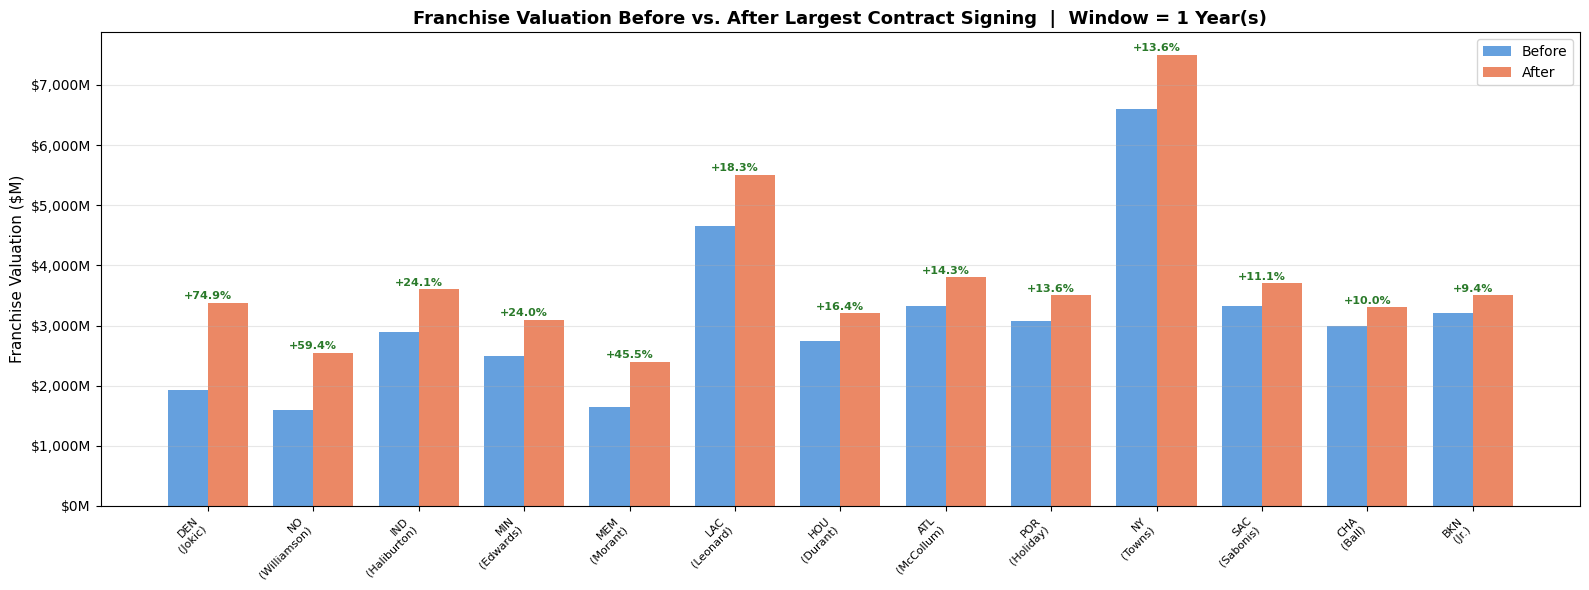

Saved: v3_before_after_valuation.png


In [27]:
plot_df = results_df.sort_values('relative_change', ascending=False).reset_index(drop=True)

x_pos = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(x_pos - width/2, plot_df['before_val'], width, label='Before', color='#4a90d9', alpha=0.85)
ax.bar(x_pos + width/2, plot_df['after_val'],  width, label='After',  color='#e8734a', alpha=0.85)

for i, (_, row) in enumerate(plot_df.iterrows()):
    pct   = row['pct_change']
    color = '#2a7a2a' if pct >= 0 else '#cc2222'
    top   = max(row['before_val'], row['after_val'])
    ax.text(i, top + 30, f'{pct:+.1f}%', ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=color)

ax.set_xticks(x_pos)
ax.set_xticklabels(
    [f"{row['team']}\n({row['player'].split()[-1]})" for _, row in plot_df.iterrows()],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel('Franchise Valuation ($M)', fontsize=11)
ax.set_title(f'Franchise Valuation Before vs. After Largest Contract Signing  |  Window = {WINDOW} Year(s)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}M'))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('v3_before_after_valuation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v3_before_after_valuation.png')

---
## Block 12 — Plot 2: Relative Valuation Change per Team

- Shows how much each team's valuation grew *relative to the league average*
- Positive bars = grew faster than the league; negative bars = grew slower
- This is the adjusted metric — it controls for the fact that all NBA valuations rise over time

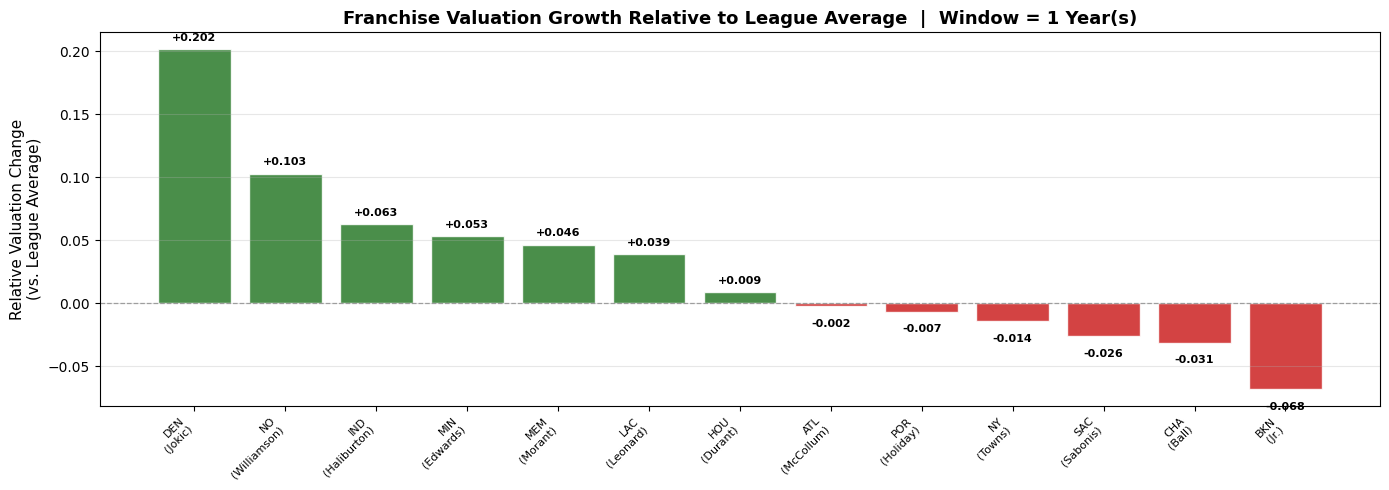

Saved: v3_relative_valuation_change.png


In [28]:
plot_df = results_df.sort_values('relative_change', ascending=False).reset_index(drop=True)

colors = ['#2a7a2a' if v >= 0 else '#cc2222' for v in plot_df['relative_change']]

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(range(len(plot_df)), plot_df['relative_change'], color=colors, alpha=0.85, edgecolor='white')

ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(
    [f"{row['team']}\n({row['player'].split()[-1]})" for _, row in plot_df.iterrows()],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel('Relative Valuation Change\n(vs. League Average)', fontsize=11)
ax.set_title(f'Franchise Valuation Growth Relative to League Average  |  Window = {WINDOW} Year(s)',
             fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.9, alpha=0.7)
ax.grid(axis='y', alpha=0.3)

for i, (_, row) in enumerate(plot_df.iterrows()):
    v      = row['relative_change']
    offset = 0.005 if v >= 0 else -0.018
    ax.text(i, v + offset, f'{v:+.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('v3_relative_valuation_change.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v3_relative_valuation_change.png')

---
## Block 13 — Plot 3: Contract Size vs. Relative Valuation Change (Scatter + Regression)

- Each dot is one team
- X-axis: contract AAV in millions
- Y-axis: relative valuation change (above/below league average growth)
- The regression line shows the overall trend
- Points above the dotted zero line = team grew faster than the league; below = slower

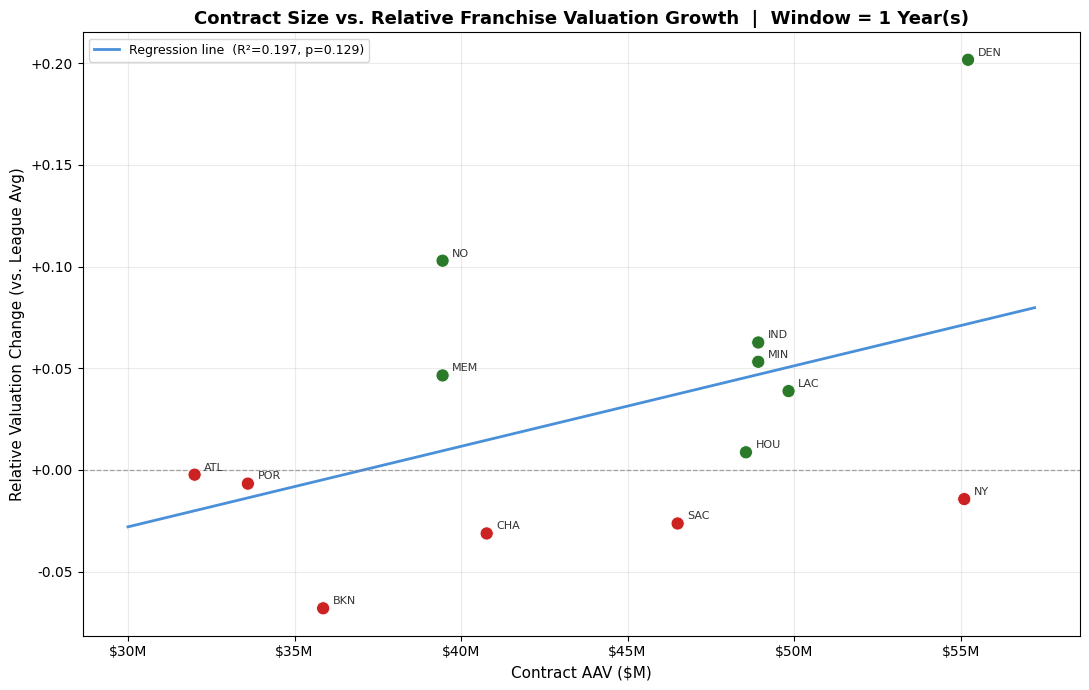

Saved: v3_contract_vs_valuation_change.png


In [29]:
x = results_df['aav_millions'].values
y = results_df['relative_change'].values

slope, intercept, r_value, p_value_reg, std_err = stats.linregress(x, y)
line_x = np.linspace(x.min() - 2, x.max() + 2, 100)
line_y = slope * line_x + intercept

fig, ax = plt.subplots(figsize=(11, 7))

colors = ['#2a7a2a' if v >= 0 else '#cc2222' for v in y]
ax.scatter(x, y, c=colors, s=90, zorder=3, edgecolors='white', linewidths=0.6)

for i, row in results_df.iterrows():
    ax.annotate(
        f"{row['team']}",
        (row['aav_millions'], row['relative_change']),
        textcoords='offset points', xytext=(7, 3),
        fontsize=8, color='#333333'
    )

ax.plot(line_x, line_y, color='#4a90d9', linewidth=2,
        label=f'Regression line  (R²={r_value**2:.3f}, p={p_value_reg:.3f})')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.9, alpha=0.7)

ax.set_xlabel('Contract AAV ($M)', fontsize=11)
ax.set_ylabel('Relative Valuation Change (vs. League Avg)', fontsize=11)
ax.set_title(f'Contract Size vs. Relative Franchise Valuation Growth  |  Window = {WINDOW} Year(s)',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.2f}'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('v3_contract_vs_valuation_change.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v3_contract_vs_valuation_change.png')

---
## Block 14 — Summary Table

- A clean printout of every team, their contract, and all three valuation metrics
- Sorted by relative valuation change so it's easy to see who outpaced the league and who didn't
- **Relative change** is the headline number — raw % growth is included for reference

In [30]:
summary = results_df[[
    'team', 'player', 'contract_start', 'aav_millions',
    'before_val', 'after_val', 'raw_change', 'pct_change', 'relative_change'
]].copy()

summary = summary.sort_values('relative_change', ascending=False).reset_index(drop=True)

summary.columns = ['Team', 'Player', 'Start', 'AAV ($M)',
                   'Val Before ($M)', 'Val After ($M)', 'Raw Change ($M)', 'Raw %', 'Rel Change']

summary['AAV ($M)']       = summary['AAV ($M)'].map('${:.1f}M'.format)
summary['Val Before ($M)']= summary['Val Before ($M)'].map('${:,.0f}M'.format)
summary['Val After ($M)'] = summary['Val After ($M)'].map('${:,.0f}M'.format)
summary['Raw Change ($M)']= summary['Raw Change ($M)'].map(lambda v: f'${v:+,.0f}M')
summary['Raw %']          = summary['Raw %'].map('{:+.1f}%'.format)
summary['Rel Change']     = summary['Rel Change'].map('{:+.3f}'.format)

print(f'V3 Summary  |  Window = {WINDOW} year(s)')
print('=' * 100)
print(summary.to_string(index=False))
print('=' * 100)
print(f'\nTeams that outpaced league average: {(results_df["relative_change"] > 0).sum()}')
print(f'Teams that underperformed league average: {(results_df["relative_change"] < 0).sum()}')
print(f'Mean relative change: {results_df["relative_change"].mean():+.4f}')

V3 Summary  |  Window = 1 year(s)
Team             Player  Start AAV ($M) Val Before ($M) Val After ($M) Raw Change ($M)  Raw % Rel Change
 DEN       Nikola Jokic   2023   $55.2M         $1,930M        $3,375M        $+1,445M +74.9%     +0.202
  NO    Zion Williamson   2023   $39.4M         $1,600M        $2,550M          $+950M +59.4%     +0.103
 IND  Tyrese Haliburton   2024   $48.9M         $2,900M        $3,600M          $+700M +24.1%     +0.063
 MIN    Anthony Edwards   2024   $48.9M         $2,500M        $3,100M          $+600M +24.0%     +0.053
 MEM          Ja Morant   2023   $39.4M         $1,650M        $2,400M          $+750M +45.5%     +0.046
 LAC      Kawhi Leonard   2024   $49.8M         $4,650M        $5,500M          $+850M +18.3%     +0.039
 HOU       Kevin Durant   2022   $48.6M         $2,750M        $3,200M          $+450M +16.4%     +0.009
 ATL      C.J. McCollum   2024   $32.0M         $3,325M        $3,800M          $+475M +14.3%     -0.002
 POR       Jrue Holid